# Лабораторная работа №1
## Разведочный анализ данных. Исследование и визуализация данных

**Выполнила:** Артёмова Дарья Артёмовна
**Группа:** ИБМ3-64Б
**Дата:** 01.03.2026

In [ ]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Загружаем данные
iris = load_iris()

# Создаем таблицу
df = pd.DataFrame(
    data=np.c_[iris['data'], iris['target']],
    columns=iris['feature_names'] + ['target']
)

# Добавляем названия видов
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Показываем первые строки
df.head()

In [ ]:
!pip install scikit-learn

In [16]:
from sklearn.datasets import load_iris
print("Библиотека найдена!")
iris = load_iris()
print("Данные загружены!")
print("Названия признаков:", iris.feature_names)
print("Названия видов:", iris.target_names)

Библиотека найдена!
Данные загружены!
Названия признаков: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Названия видов: ['setosa' 'versicolor' 'virginica']


In [7]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Настройка графиков
%matplotlib inline
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Библиотеки загружены")

Библиотеки загружены


In [6]:
# Загружаем данные
iris = load_iris()

# Создаем таблицу (как в твоем примере)
df = pd.DataFrame(
    data=np.c_[iris['data'], iris['target']],
    columns=iris['feature_names'] + ['target']
)

# Добавляем названия видов
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("Данные загружены")
print(f"Размер таблицы: {df.shape}")
df.head()

Данные загружены
Размер таблицы: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa


## 1. Текстовое описание набора данных

**Название:** Iris (Ирисы Фишера)

**Источник:** Классический датасет, собранный ботаником Эдгаром Андерсоном и обработанный статистиком Рональдом Фишером в 1936 году.

**Содержание:** 150 образцов ирисов трёх видов:
- setosa (ирис щетинистый) - 50 образцов
- versicolor (ирис разноцветный) - 50 образцов  
- virginica (ирис виргинский) - 50 образцов

**Признаки:**
1. sepal length (cm) - длина чашелистика
2. sepal width (cm) - ширина чашелистика
3. petal length (cm) - длина лепестка
4. petal width (cm) - ширина лепестка

In [8]:
print("ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА")
print(" " * 50)
print(f"Всего записей: {df.shape[0]}")
print(f"Всего столбцов: {df.shape[1]}")
print("\nТипы данных:")
print(df.dtypes)
print("\nПроверка на пропуски:")
print(df.isnull().sum())
print("\nСтатистическое описание:")
df.describe()

ОСНОВНЫЕ ХАРАКТЕРИСТИКИ ДАТАСЕТА
                                                  
Всего записей: 150
Всего столбцов: 6

Типы данных:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target               float64
species               object
dtype: object

Проверка на пропуски:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Статистическое описание:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Распределение по видам:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

В процентах:
species
setosa        33.333333
versicolor    33.333333
virginica     33.333333
Name: proportion, dtype: float64


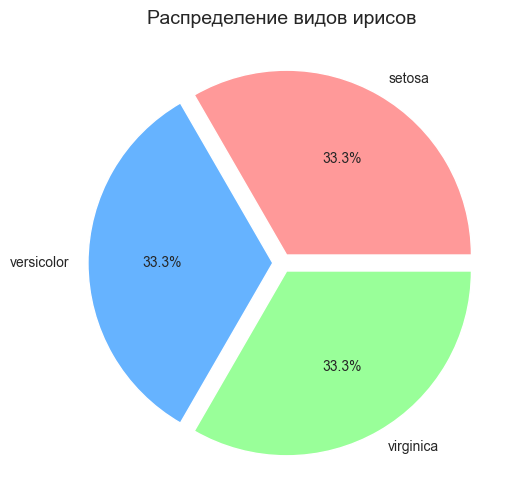

In [9]:
print("Распределение по видам:")
print(df['species'].value_counts())
print("\nВ процентах:")
print(df['species'].value_counts(normalize=True) * 100)

# Круговая диаграмма
plt.figure(figsize=(6,6))
df['species'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors=['#ff9999', '#66b3ff', '#99ff99'],
    explode=(0.05, 0.05, 0.05)
)
plt.title('Распределение видов ирисов', fontsize=14)
plt.ylabel('')
plt.show()

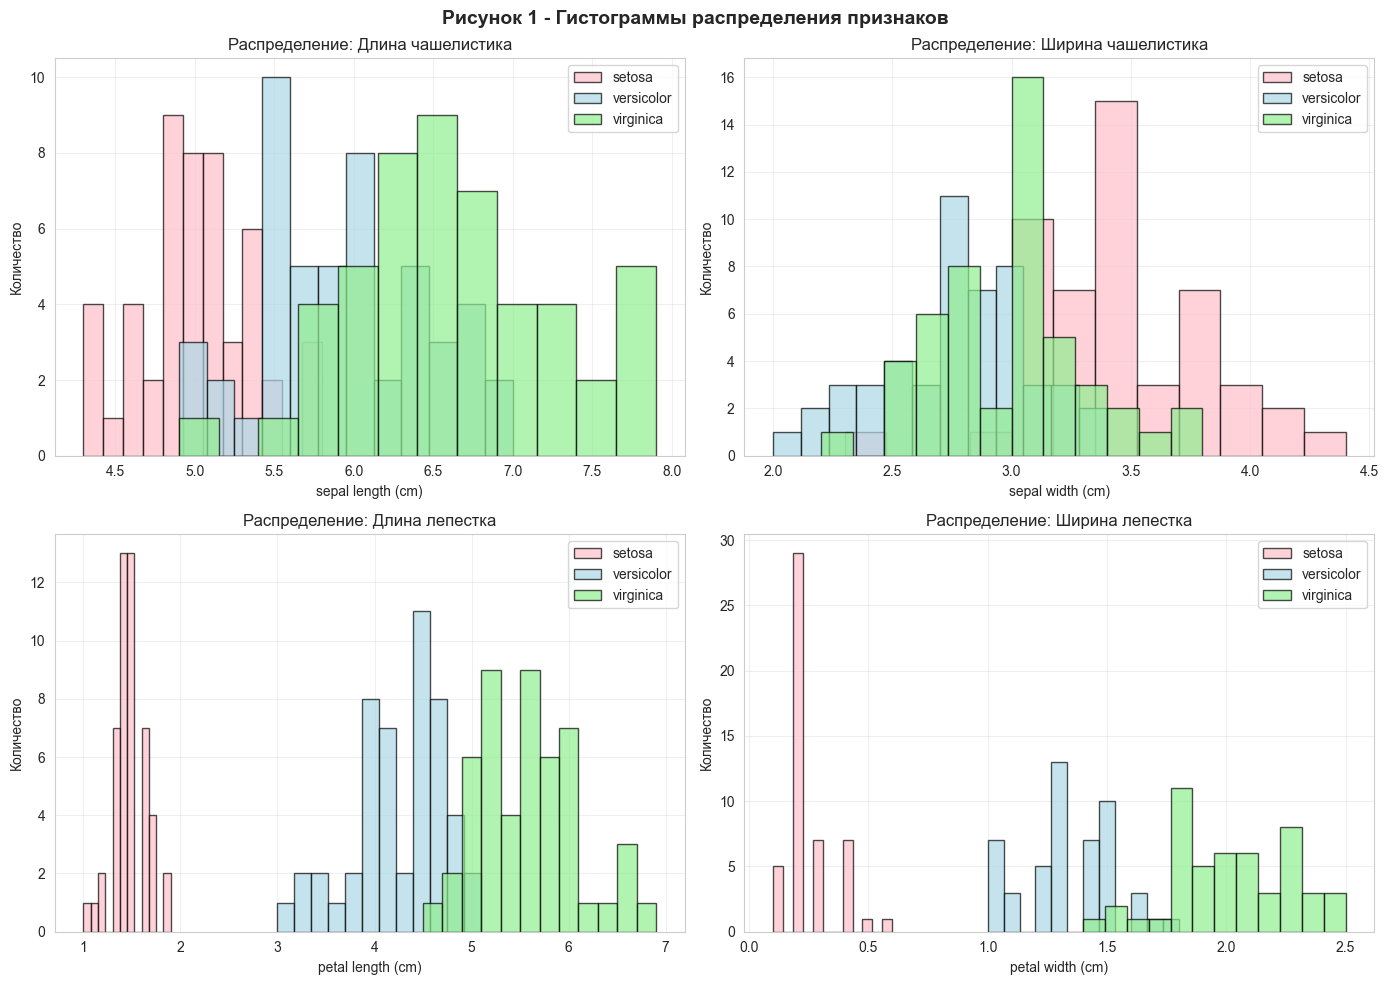

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features = iris['feature_names']
titles = ['Длина чашелистика', 'Ширина чашелистика', 
          'Длина лепестка', 'Ширина лепестка']
colors = ['pink', 'lightblue', 'lightgreen']

for idx, feature in enumerate(features):
    for species, color in zip(df['species'].unique(), colors):
        subset = df[df['species'] == species]
        axes[idx].hist(subset[feature], alpha=0.7, 
                      label=species, color=color, bins=12, 
                      edgecolor='black')
        axes[idx].set_title(f'Распределение: {titles[idx]}', fontsize=12)
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].set_ylabel('Количество', fontsize=10)
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('Рисунок 1 - Гистограммы распределения признаков', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

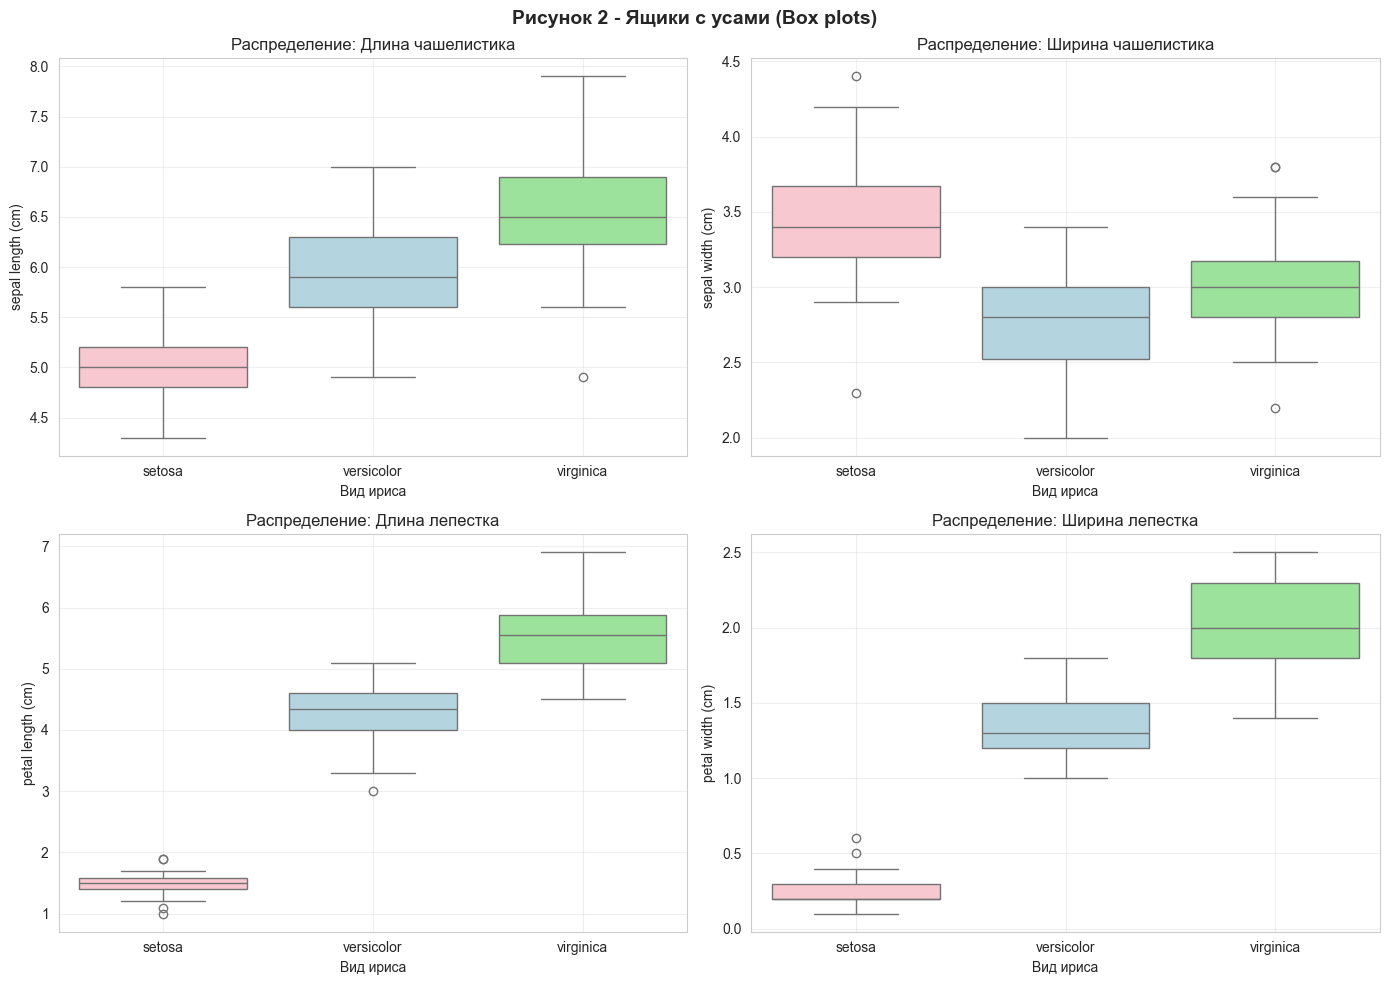

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

features = iris['feature_names']
titles = ['Длина чашелистика', 'Ширина чашелистика', 
          'Длина лепестка', 'Ширина лепестка']
colors = ['pink', 'lightblue', 'lightgreen']

for idx, feature in enumerate(features):
    sns.boxplot(x='species', y=feature, data=df, ax=axes[idx],
                hue='species', palette=colors, legend=False)
    axes[idx].set_title(f'Распределение: {titles[idx]}', fontsize=12)
    axes[idx].set_xlabel('Вид ириса', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Рисунок 2 - Ящики с усами (Box plots)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

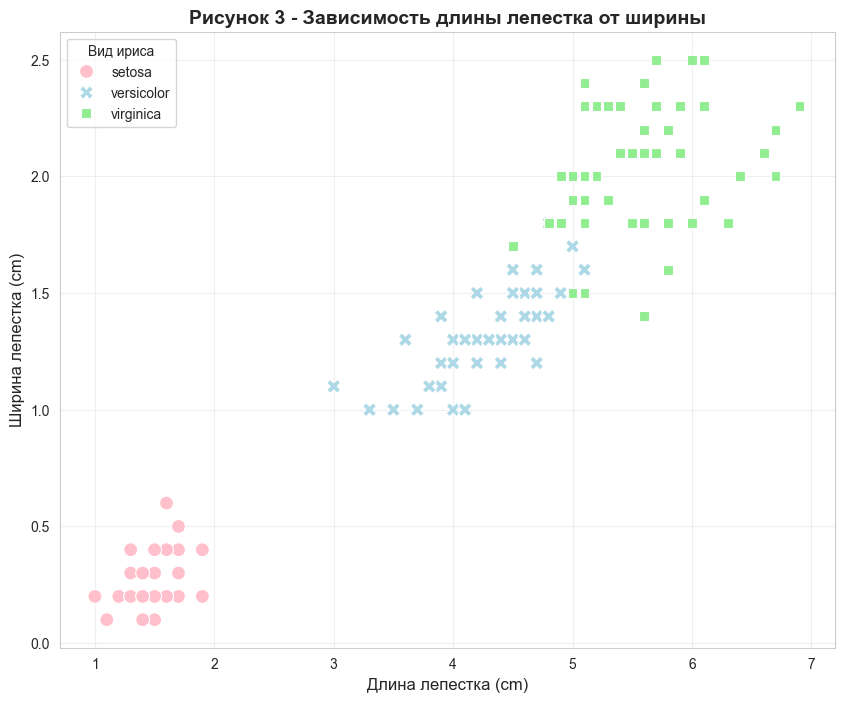

In [12]:
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    style='species',
    s=100,
    palette=['pink', 'lightblue', 'lightgreen']
)

plt.title('Рисунок 3 - Зависимость длины лепестка от ширины', 
          fontsize=14, fontweight='bold')
plt.xlabel('Длина лепестка (cm)', fontsize=12)
plt.ylabel('Ширина лепестка (cm)', fontsize=12)
plt.legend(title='Вид ириса')
plt.grid(True, alpha=0.3)
plt.show()

Строим матрицу парных зависимостей (это может занять несколько секунд)...


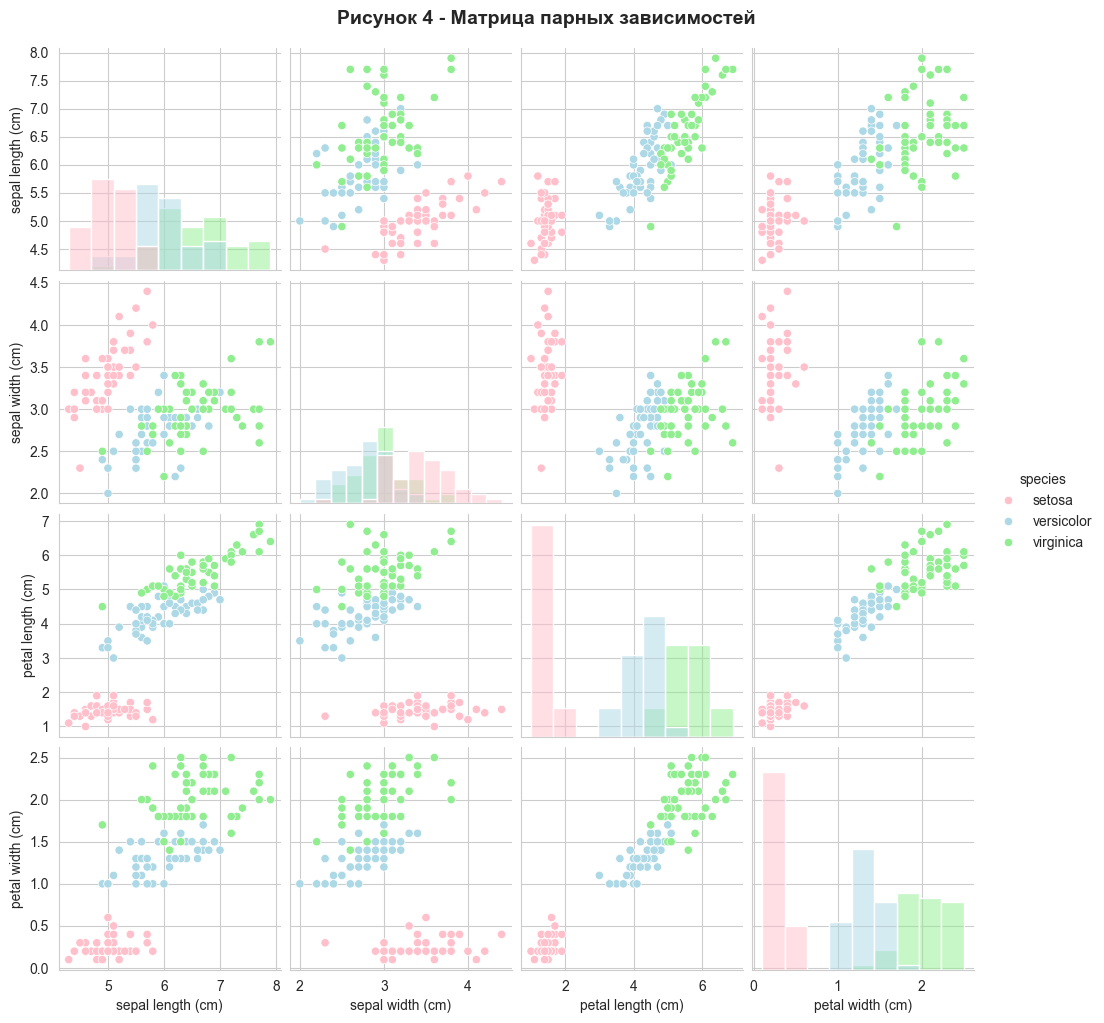

In [13]:
print("Строим матрицу парных зависимостей (это может занять несколько секунд)...")
sns.pairplot(df, hue='species', vars=iris['feature_names'],
             diag_kind='hist', palette=['pink', 'lightblue', 'lightgreen'])
plt.suptitle('Рисунок 4 - Матрица парных зависимостей', 
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

КОРРЕЛЯЦИОННАЯ МАТРИЦА:
                                                  
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   
target                      0.782561         -0.426658           0.949035   

                   petal width (cm)    target  
sepal length (cm)          0.817941  0.782561  
sepal width (cm)          -0.366126 -0.426658  
petal length (cm)          0.962865  0.949035  
petal width (cm)           1.000000  0.956547  
target                     0.956547  1.000000  


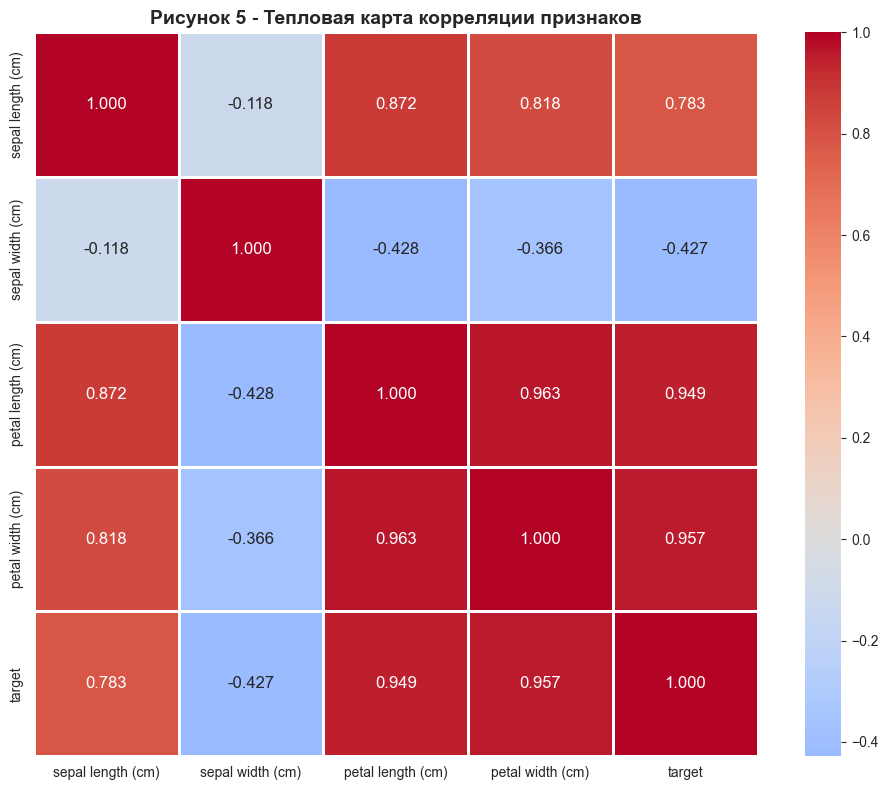

In [15]:
# Вычисляем корреляцию
corr_matrix = df[['sepal length (cm)', 'sepal width (cm)', 
                  'petal length (cm)', 'petal width (cm)', 'target']].corr()

print("КОРРЕЛЯЦИОННАЯ МАТРИЦА:")
print(" " * 50)
print(corr_matrix)

# Тепловая карта
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.3f',
            annot_kws={'size': 12})
plt.title('Рисунок 5 - Тепловая карта корреляции признаков', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ВЫВОДЫ

В ходе выполнения лабораторной работы был проведен разведочный анализ данных датасета Iris.

**Основные результаты:**

1. **Структура данных:**
   - Датасет содержит 150 образцов ирисов трёх видов (по 50 каждого)
   - Пропуски в данных отсутствуют
   - Данные сбалансированы по классам

2. **Визуальный анализ показал:**
   - Вид setosa хорошо отделяется от двух других видов по размерам лепестков
   - Виды versicolor и virginica имеют некоторое перекрытие в характеристиках
   - Наиболее информативные признаки - длина и ширина лепестка

3. **Корреляционный анализ:**
   - Сильная положительная корреляция между длиной и шириной лепестка (0.96)
   - Высокая корреляция между длиной лепестка и длиной чашелистика (0.87)
   - Слабая связь между шириной чашелистика и размерами лепестков

Таким образом, разведочный анализ позволил получить первичное понимание структуры данных.